# 1. Búsqueda informada: material para el taller

Para resolver el taller posterior, primero consolidamos las piezas de la búsqueda informada.

- $g(n)$: costo acumulado desde el inicio hasta $n$.
- $h(n)$: estimación del costo desde $n$ hasta el objetivo.
- En A*: $f(n)=g(n)+h(n)$.

**Costo Uniforme:** prioriza menor $g(n)$.  
**A\*:** prioriza menor $g(n)+h(n)$.  
**Beam Search:** conserva solo los mejores $k$ candidatos de cada nivel.

## 1.1 Entorno

In [63]:
from heapq import heappush, heappop
from itertools import count
import math
import matplotlib.pyplot as plt

print("Entorno listo")

Entorno listo


## 1.2 Heurística

Costo Uniforme solo utiliza información sobre el costo ya recorrido: $g(n)$. Para orientar la búsqueda hacia el objetivo incorporamos una estimación del costo mínimo restante desde el nodo $n$ hasta el objetivo:

$$h(n)$$

La heurística $h(n)$ intenta aproximar el costo real mínimo restante $h^*(n)$:

$$h(n)\approx h^*(n)$$

Una heurística es **admisible** cuando nunca sobreestima el costo real:

$$\boxed{h(n)\leq h^*(n)}$$

> **La heurística no tiene que acertar exactamente. Tiene que estimar.**  
> Una heurística demasiado débil puede aportar poca información. Una heurística que sobreestima puede orientar de manera agresiva la búsqueda, pero pierde garantías de optimalidad.

## 1.3 A*

A* combina costo acumulado y estimación:

$$\boxed{f(n)=g(n)+h(n)}$$

Se expande primero el nodo con menor $f(n)$.

## 1.4 Caso aplicado: cuadrícula

Trabajaremos con un mapa:

- `0`: celda libre
- `1`: obstáculo
- acciones: arriba, abajo, izquierda y derecha
- costo de cada movimiento: 1

Para A* usaremos distancia Manhattan:

$$h(n)=|x_n-x_g|+|y_n-y_g|$$

In [64]:
mapa = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,1,0,1,0,0,0],
    [0,0,0,0,1,1,0],
    [0,1,1,0,0,0,0],
    [0,0,0,0,1,0,0],
]
INICIO=(0,0); OBJETIVO=(6,6)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

### 1.4.1 Costo Uniforme

In [65]:
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 35}

### 1.4.2 A*

In [66]:
def astar_mapa(mapa, inicio, objetivo, heuristica=manhattan):
    tie = count()
    frontera = [
        (heuristica(inicio, objetivo), 0, next(tie), inicio, [inicio])
    ]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, nodo, camino = heappop(frontera)

        if g != mejor_g.get(nodo):
            continue

        expandidos += 1

        if nodo == objetivo:
            return {
                "camino": camino,
                "costo": g,
                "expandidos": expandidos,
            }
        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1

            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                nf = ng + heuristica(vecino, objetivo)

                heappush(
                    frontera,
                    (nf, ng, next(tie), vecino, camino + [vecino])
                )

    return None
resultado_astar_mapa = astar_mapa(mapa, INICIO, OBJETIVO)

### 1.4.3 Visualización

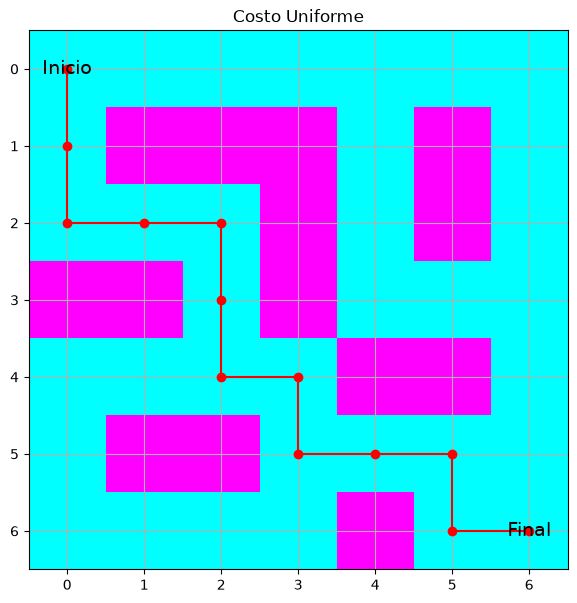

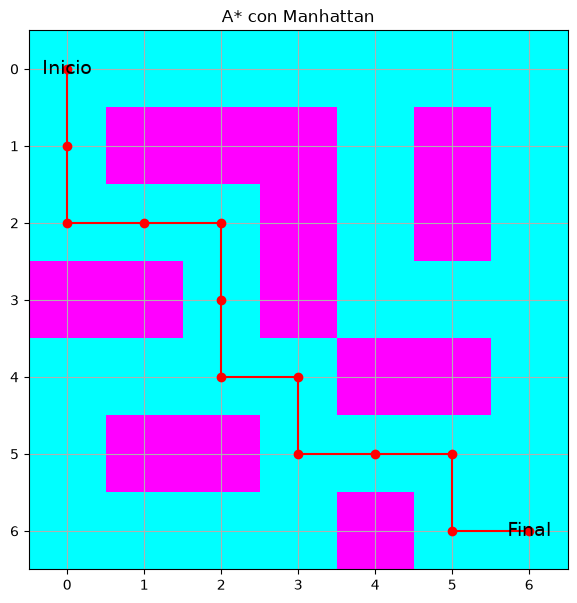

In [67]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

## 1.5 Beam Search

Beam Search limita deliberadamente la cantidad de estados conservados en cada nivel.

$$k=\text{beam width}$$

Si $k=2$, solo se mantienen los dos estados más prometedores del nivel.

Ventaja: reduce memoria y exploración.  
Riesgo: puede descartar un estado que conduzca a la mejor solución. Por eso no garantiza optimalidad y puede fallar aunque exista solución.

In [68]:
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
        
    return {
    "camino": None,
    "costo": None,
    "expandidos": expandidos,
    "beam_width": beam_width,
}

resultado_beam=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=3)
resultado_beam

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 31,
 'beam_width': 3}

### 1.5.1 Experimentar con diferentes anchos de haz

In [69]:
resultados_beam={}
for k in [1,2,3,5,10]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: {'camino': None, 'costo': None, 'expandidos': 15, 'beam_width': 1},
 2: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 24,
  'beam_width': 2},
 3: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 31,
  'beam_width': 3},
 5: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 5},
 10: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 10}}

## 1.6 Reto final: el 8-puzzle

Compare tres estrategias sobre el mismo problema:

1. BFS
2. A* con fichas fuera de lugar
3. A* con distancia Manhattan

Mida:
- longitud de la solución;
- estados expandidos;
- tiempo de ejecución.

Heurísticas sugeridas:

$$h_1(n)=\text{número de fichas fuera de lugar}$$

$$h_2(n)=\sum_i (|x_i-x_i^*|+|y_i-y_i^*|)$$

In [70]:
estado_inicial = (
    1, 2, 3,
    4, 5, 0,
    6, 8, 7,
)

estado_objetivo = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0,
)

estado_inicial, estado_objetivo

((1, 2, 3, 4, 5, 0, 6, 8, 7), (1, 2, 3, 4, 5, 6, 7, 8, 0))

### 1.6.1 Generación de sucesores

El `0` representa la casilla vacía.

La siguiente función genera todos los estados alcanzables mediante **un movimiento válido**.

In [71]:
def sucesores_8_puzzle(estado):
    estado = list(estado)
    indice_cero = estado.index(0)

    fila, columna = divmod(indice_cero, 3)

    movimientos = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
    ]

    sucesores = []

    for df, dc in movimientos:
        nf, nc = fila + df, columna + dc

        if 0 <= nf < 3 and 0 <= nc < 3:
            nuevo_indice = nf * 3 + nc
            nuevo = estado.copy()

            nuevo[indice_cero], nuevo[nuevo_indice] = (
                nuevo[nuevo_indice],
                nuevo[indice_cero],
            )

            sucesores.append(tuple(nuevo))

    return sucesores


sucesores_8_puzzle(estado_inicial)

[(1, 2, 0, 4, 5, 3, 6, 8, 7),
 (1, 2, 3, 4, 5, 7, 6, 8, 0),
 (1, 2, 3, 4, 0, 5, 6, 8, 7)]

### 1.6.2 BFS del 8-puzzle

Referencia para poder comparar A* con una búsqueda no informada.

In [72]:
from collections import deque

def bfs_8_puzzle(estado_inicial, estado_objetivo):
    cola = deque([(estado_inicial, [estado_inicial])])
    visitados = {estado_inicial}

    while cola:
        estado, camino = cola.popleft()

        for sucesor in sucesores_8_puzzle(estado):
            if sucesor not in visitados:
                visitados.add(sucesor)

                if sucesor == estado_objetivo:
                    return {
                        "camino": camino + [sucesor],
                        "movimientos": len(camino),
                        "explorados": len(visitados),
                    }

                cola.append((sucesor, camino + [sucesor]))

    return None


inicio_solucionable = (1, 2, 3, 4, 5, 0, 6, 7, 8)
resultado_bfs = bfs_8_puzzle(inicio_solucionable, estado_objetivo)

print("Movimientos:", resultado_bfs["movimientos"])
print("Estados explorados:", resultado_bfs["explorados"])

Movimientos: 13
Estados explorados: 2710


### 1.6.3 A* del 8-puzzle

Complete la implementación de A* para el 8-puzzle reutilizando `sucesores_8_puzzle`. Puede apoyarse en `ucs_mapa` y `astar_mapa`. Recuerde que el taller pide compararlo con BFS.

In [73]:
# TODO: implemente aquí A* para el 8-puzzle.

from heapq import heappush, heappop
from itertools import count
import math


def astar_8_puzzle(estado_inicial, estado_objetivo, heuristica):
    tie = count()
    frontera = [
        (
            heuristica(estado_inicial, estado_objetivo),
            0,
            next(tie),
            estado_inicial,
            [estado_inicial],
        )
    ]

    mejor_g = {estado_inicial: 0}
    expandidos = 0

    while frontera:
        f, g, _, estado, camino = heappop(frontera)

        if g != mejor_g.get(estado):
            continue

        expandidos += 1

        if estado == estado_objetivo:
            return {
                "camino": camino,
                "movimientos": g,
                "expandidos": expandidos,
            }

        for sucesor in sucesores_8_puzzle(estado):
            nuevo_g = g + 1

            if nuevo_g < mejor_g.get(sucesor, math.inf):
                mejor_g[sucesor] = nuevo_g
                nuevo_f = nuevo_g + heuristica(
                    sucesor, estado_objetivo
                )

                heappush(
                    frontera,
                    (
                        nuevo_f,
                        nuevo_g,
                        next(tie),
                        sucesor,
                        camino + [sucesor],
                    )
                )

    return {
        "camino": None,
        "movimientos": None,
        "expandidos": expandidos,
    }

# 2. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.

### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.

## 3. Solución del taller
### 3.1 Parte 1 — Cuadrícula
El enunciado pide construir un mapa de al menos 12 × 12 y ejecutar sobre él Costo Uniforme, A* y Beam Search con k = 1, 2, 4, 8, comparando costo de solución, estados expandidos y capacidad de encontrar una solución.
Construimos un mapa 12 × 12 con pasillos, cuellos de botella y un callejón sin salida en la columna izquierda. El inicio está en (0, 0) y el objetivo en (11, 11); cada movimiento cuesta 1.

In [74]:
mapa12 = [
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,0,0,0,1,1,1,0],
    [0,1,0,0,0,0,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,1,1,0,1,0],
    [0,0,0,1,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,1,1,1,1,0],
    [0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,1,0],
    [0,0,0,0,0,0,0,1,0,0,0,0],
    [0,1,1,0,1,1,1,1,0,1,1,0],
    [0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,1,0,0,0,0,0,0,1,0,0],
]

INICIO_12 = (0, 0)
OBJETIVO_12 = (11, 11)

print(f"Mapa {len(mapa12)} x {len(mapa12[0])}")
print(f"Inicio {INICIO_12}, objetivo {OBJETIVO_12}")
for fila in mapa12:
    print("".join("#" if celda == 1 else "." for celda in fila))

Mapa 12 x 12
Inicio (0, 0), objetivo (11, 11)
............
.####...###.
.#........#.
.#.######.#.
...#........
.###.######.
.....#......
.#####.####.
.......#....
.##.####.##.
.........#..
..#......#..


In [75]:
resultados_parte1 = {}

resultados_parte1["Costo Uniforme"] = ucs_mapa(mapa12, INICIO_12, OBJETIVO_12)
resultados_parte1["A* Manhattan"] = astar_mapa(mapa12, INICIO_12, OBJETIVO_12)

for k in [1, 2, 4, 8]:
    resultados_parte1[f"Beam k={k}"] = beam_search_mapa(
        mapa12, INICIO_12, OBJETIVO_12, beam_width=k
    )

print(f"{'Algoritmo':<18} {'Solución':<9} {'Costo':<6} {'Expandidos'}")
print("-" * 46)
for nombre, res in resultados_parte1.items():
    encontrado = res is not None and res["camino"] is not None

    solucion = "Sí" if encontrado else "No"
    costo = res["costo"] if encontrado else "-"
    expandidos = res["expandidos"] if res is not None else "-"

    print(f"{nombre:<18} {solucion:<9} {costo:<6} {expandidos}")

Algoritmo          Solución  Costo  Expandidos
----------------------------------------------
Costo Uniforme     Sí        22     93
A* Manhattan       Sí        22     73
Beam k=1           No        -      13
Beam k=2           Sí        26     47
Beam k=4           Sí        26     76
Beam k=8           Sí        22     93


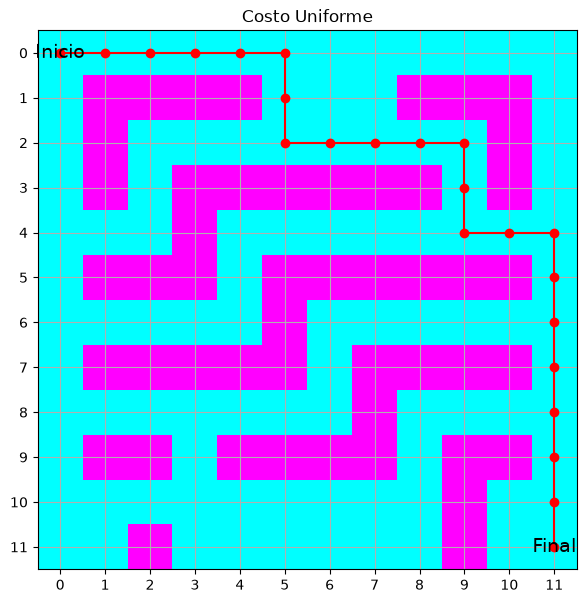

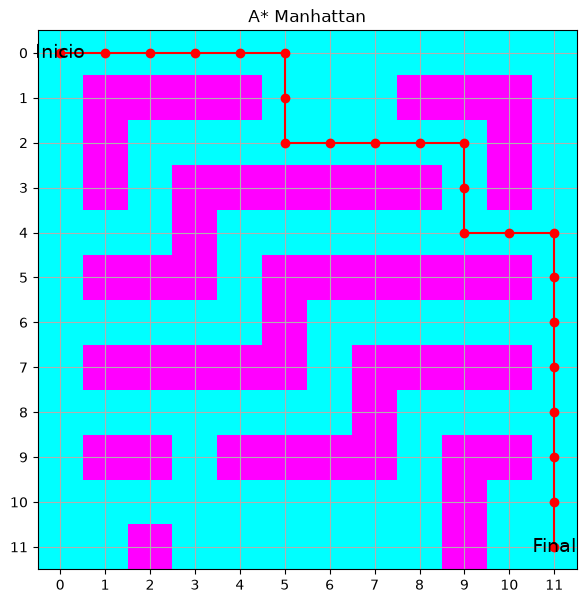

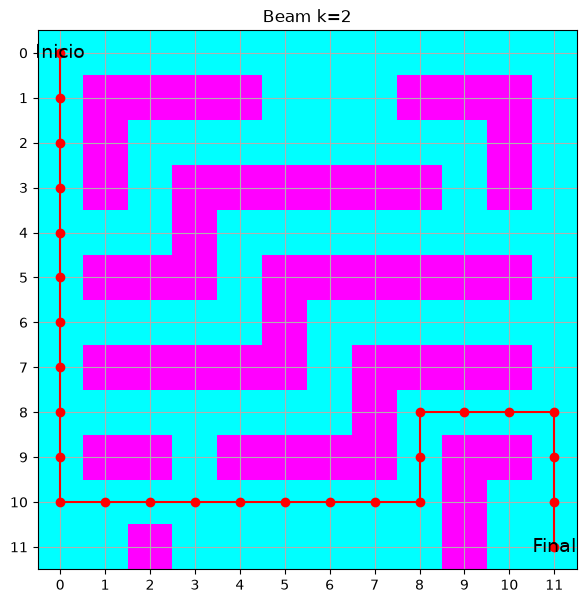

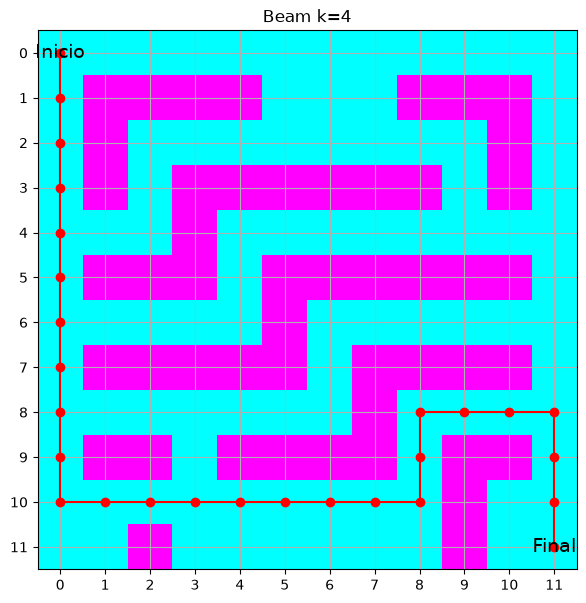

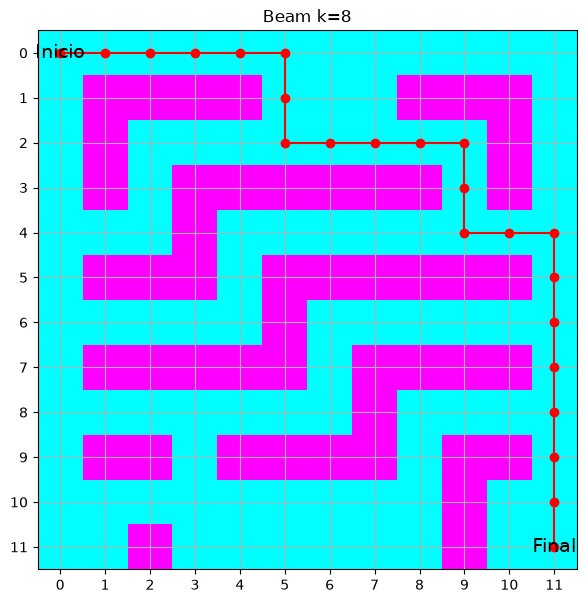

In [76]:
caminos_con_solucion = {
    nombre: res
    for nombre, res in resultados_parte1.items()
    if res is not None and res["camino"] is not None
}

for nombre, res in caminos_con_solucion.items():
    mostrar_mapa(
        mapa12,
        camino=res["camino"],
        inicio=INICIO_12,
        objetivo=OBJETIVO_12,
        titulo=nombre,
    )


Hicimos un mapa de `12 × 12` con un inicio en `(0, 0)`, un objetivo en `(11, 11)` y obstáculos que forman pasillos y cuellos de botella; entre ellos hay un callejón sin salida que sirve para ver cómo se comporta cada algoritmo. Reutilicé las funciones de las secciones 1.4 y 1.5.

### Resultados

| Algoritmo | ¿Encontró solución? | Costo | Estados expandidos |
|---|---:|---:|---:|
| Costo Uniforme | Sí | 22 | 93 |
| A* (Manhattan) | Sí | 22 | 73 |
| Beam k=1 | No | — | 13 |
| Beam k=2 | Sí | 26 | 47 |
| Beam k=4 | Sí | 26 | 76 |
| Beam k=8 | Sí | 22 | 93 |

### Qué observé

- **Costo Uniforme:** encontró el camino óptimo de costo 22 y expandió 93 estados.
- **A* con Manhattan:** encontró el mismo costo óptimo de 22, pero expandió 73 estados, gracias a la orientación de la heurística.
- **Beam k=1:** procesó 13 estados y terminó sin solución porque descartó alternativas y agotó los candidatos disponibles.
- **Beam k=2 y k=4:** encontraron caminos de costo 26, superiores al óptimo, porque la poda descartó alternativas que permitían obtener una solución mejor.
- **Beam k=8:** encontró el óptimo de costo 22 en este mapa, aunque no garantiza obtenerlo en todos los problemas.

### Conclusión

En este experimento, un haz pequeño permitió explorar menos estados, pero produjo caminos más largos o no encontró solución. A* con Manhattan redujo la exploración respecto a Costo Uniforme sin perder la calidad de la solución. No se midió el tiempo en esta parte, por lo que la comparación se refiere a los estados expandidos.

# 3.2 - Heurísticas

In [77]:
def euclidiana(a, b):
    return math.sqrt(
        (a[0] - b[0])**2 +
        (a[1] - b[1])**2
    )

In [78]:
resultados_parte2 = {
    "Manhattan": astar_mapa(
        mapa12, INICIO_12, OBJETIVO_12,
        heuristica=manhattan
    ),
    "Euclidiana": astar_mapa(
        mapa12, INICIO_12, OBJETIVO_12,
        heuristica=euclidiana
    ),
}

print(f"{'Heurística':<15} {'Costo':<8} {'Expandidos'}")
print("-" * 35)
for nombre, resultado in resultados_parte2.items():
    if resultado is None:
        print(f"{nombre:<15} Sin solución")
    else:
        print(
            f"{nombre:<15} "
            f"{resultado['costo']:<8} "
            f"{resultado['expandidos']}"
        )

Heurística      Costo    Expandidos
-----------------------------------
Manhattan       22       73
Euclidiana      22       81


### Análisis de heurística

Se comparó A* con las heurísticas Manhattan y euclidiana sobre el mismo mapa de 12 × 12. Ambas encontraron una solución de costo 22, pero Manhattan expandió 73 estados y euclidiana 81.

Manhattan orientó mejor la búsqueda en este experimento: expandió 8 estados menos para obtener el mismo costo. Esto se explica porque los movimientos permitidos son únicamente horizontales y verticales. La distancia euclidiana mide en línea recta y proporciona una estimación menor o igual que Manhattan, por lo que resulta menos informativa en este entorno.

Ambas heurísticas son admisibles: ninguna sobreestima el costo mínimo restante. Los obstáculos pueden alargar el recorrido real, pero no invalidan esas estimaciones.

# 3.3 - 8-puzzle

In [79]:
import time
from collections import deque

inicio_puzzle = (1, 2, 3,
                 4, 5, 0,
                 6, 7, 8)

objetivo_puzzle = (1, 2, 3,
                   4, 5, 6,
                   7, 8, 0)


def fichas_fuera_lugar(estado, objetivo):
    return sum(
        ficha != 0 and ficha != objetivo[i]
        for i, ficha in enumerate(estado)
    )


def manhattan_puzzle(estado, objetivo):
    posiciones_objetivo = {
        ficha: divmod(i, 3)
        for i, ficha in enumerate(objetivo)
    }

    distancia = 0

    for i, ficha in enumerate(estado):
        if ficha == 0:
            continue

        fila, columna = divmod(i, 3)
        fila_meta, columna_meta = posiciones_objetivo[ficha]

        distancia += (
            abs(fila - fila_meta) +
            abs(columna - columna_meta)
        )

    return distancia

In [80]:
def bfs_8_puzzle_comparacion(estado_inicial, estado_objetivo):
    cola = deque([(estado_inicial, [estado_inicial])])
    visitados = {estado_inicial}
    expandidos = 0

    while cola:
        estado, camino = cola.popleft()
        expandidos += 1

        if estado == estado_objetivo:
            return {
                "camino": camino,
                "movimientos": len(camino) - 1,
                "expandidos": expandidos,
            }

        for sucesor in sucesores_8_puzzle(estado):
            if sucesor not in visitados:
                visitados.add(sucesor)
                cola.append((sucesor, camino + [sucesor]))

    return {
        "camino": None,
        "movimientos": None,
        "expandidos": expandidos,
    }

In [81]:
pruebas = [
    ("BFS", bfs_8_puzzle_comparacion, ()),
    ("A* fuera de lugar", astar_8_puzzle, (fichas_fuera_lugar,)),
    ("A* Manhattan", astar_8_puzzle, (manhattan_puzzle,)),
]

resultados_parte3 = {}

for nombre, algoritmo, extras in pruebas:
    inicio_tiempo = time.perf_counter()

    resultado = algoritmo(
        inicio_puzzle,
        objetivo_puzzle,
        *extras
    )

    resultado["tiempo"] = time.perf_counter() - inicio_tiempo
    resultados_parte3[nombre] = resultado

print(
    f"{'Estrategia':<20} "
    f"{'Movimientos':<13} "
    f"{'Expandidos':<12} "
    f"{'Tiempo (s)'}"
)
print("-" * 60)

for nombre, resultado in resultados_parte3.items():
    movimientos = (
        resultado["movimientos"]
        if resultado["camino"] is not None
        else "Sin solución"
    )

    print(
        f"{nombre:<20} "
        f"{movimientos:<13} "
        f"{resultado['expandidos']:<12} "
        f"{resultado['tiempo']:.6f}"
    )

Estrategia           Movimientos   Expandidos   Tiempo (s)
------------------------------------------------------------
BFS                  13            2710         0.007133
A* fuera de lugar    13            190          0.001096
A* Manhattan         13            84           0.000653


# Análisis del 8-puzzle

Los tres algoritmos encontraron una solución óptima de 13 movimientos. Sin embargo, BFS expandió 2710 estados, A* con fichas fuera de lugar expandió 190 y A* con Manhattan solamente 84.

Las heurísticas permitieron orientar la búsqueda y reducir la exploración sin aumentar la longitud de la solución. Manhattan fue más informativa porque considera cuántas posiciones debe desplazarse cada ficha hasta su destino, mientras que fichas fuera de lugar solo cuenta cuántas están mal ubicadas.

En esta ejecución, A* con Manhattan también obtuvo el menor tiempo. Los tiempos pueden variar entre ejecuciones, por lo que estos valores corresponden a una medición concreta.

# ¿Puede una búsqueda más rápida producir una solución peor?

Sí. Reducir la exploración puede producir una solución de mayor costo o impedir encontrar una solución.

En la cuadrícula, Beam Search con `k=2` expandió 47 estados y encontró un camino de costo 26. En comparación, Costo Uniforme expandió 93 estados y encontró el óptimo de costo 22. Beam con `k=1` procesó solo 13 estados, pero no encontró solución. Estos resultados muestran menor exploración, aunque en esa parte no se midió el tiempo.

Sin embargo, una búsqueda más rápida no necesariamente produce una solución peor. En el 8-puzzle, A* con Manhattan encontró los mismos 13 movimientos que BFS, exploró muchos menos estados y tardó menos en la ejecución registrada. El resultado depende de la estrategia y de la información utilizada para orientar la búsqueda.